# timeline — multi-series temporal visualisation

Renders one or more time-series as connected dot-chains. Each series gets a distinct
colour from `CLUSTER_PALETTE`.

```
timeline(data, values=None, *, x_col, y_cols, node_size, edge_size,
         edge_opacity, independent_y, width, height, padding,
         interactive, storyboard) -> np.ndarray | None
```

**Input modes**
| Input | Usage |
|-------|-------|
| Two arrays | `timeline(dates, values)` |
| Dict | `timeline({"A": (dates_a, vals_a), "B": (dates_b, vals_b)})` |
| DataFrame + `y_cols` | `timeline(df, x_col="date", y_cols=["col1", "col2"])` |

In [1]:
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display
import justviz as jv

## 1 — Single series (numeric timestamps)

timeline: 1 series, 3,772 instances, 1000×500, render 211.2ms


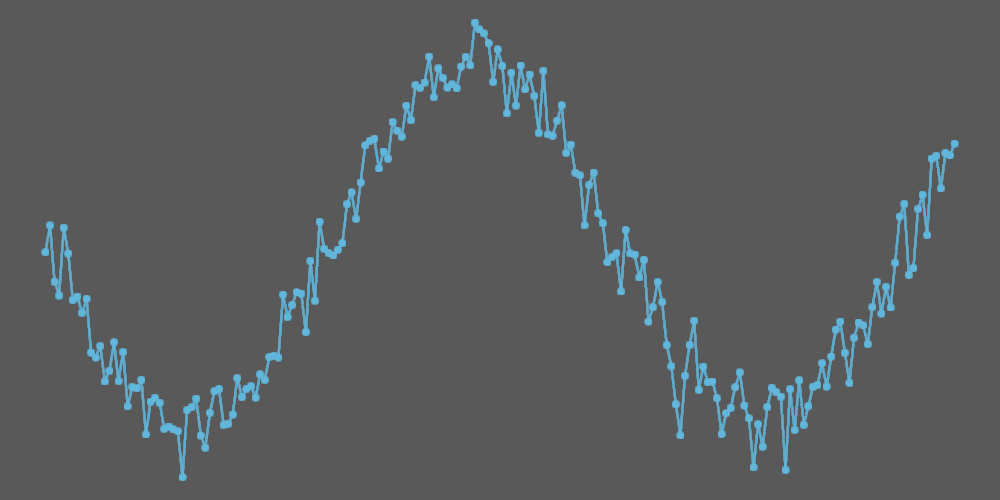

In [2]:
rng = np.random.default_rng(42)
n = 200
t = np.linspace(0, 10, n).astype(np.float32)
v = (np.sin(t) + rng.normal(0, 0.15, n)).astype(np.float32)

img = jv.timeline(t, v, node_size=4.0, edge_size=1.5, edge_opacity=0.7,
                  width=1000, height=500)
display(Image.fromarray(img, mode='RGBA'))

## 2 — Multiple series via dict

timeline: 3 series, 14,752 instances, 1100×600, render 9.0ms


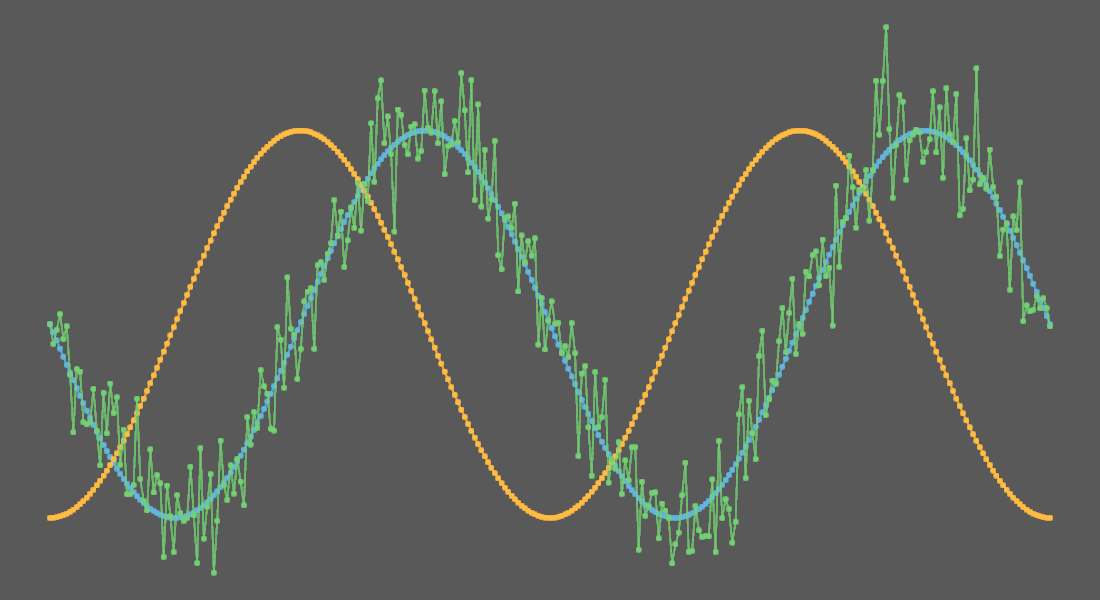

In [3]:
rng = np.random.default_rng(7)
t = np.linspace(0, 4 * np.pi, 300).astype(np.float32)

series_data = {
    "sin": (t, np.sin(t).astype(np.float32)),
    "cos": (t, np.cos(t).astype(np.float32)),
    "sin+noise": (t, (np.sin(t) + rng.normal(0, 0.2, len(t))).astype(np.float32)),
}

img = jv.timeline(series_data, node_size=3.0, edge_size=1.2, edge_opacity=0.6,
                  width=1100, height=600)
display(Image.fromarray(img, mode='RGBA'))

## 3 — Independent Y normalisation

With `independent_y=True`, each series is individually normalised to `[0, 1]`, making scales comparable even when magnitudes differ.

independent_y=False (raw values)
timeline: 3 series, 24,243 instances, 1000×500, render 10.5ms


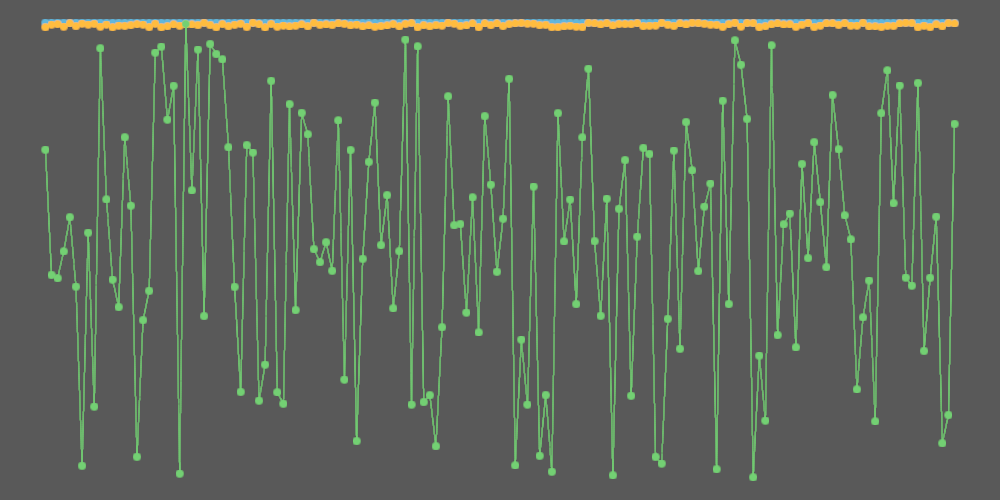

independent_y=True (each series normalised 0→1)
timeline: 3 series, 69,226 instances, 1000×500, render 22.2ms


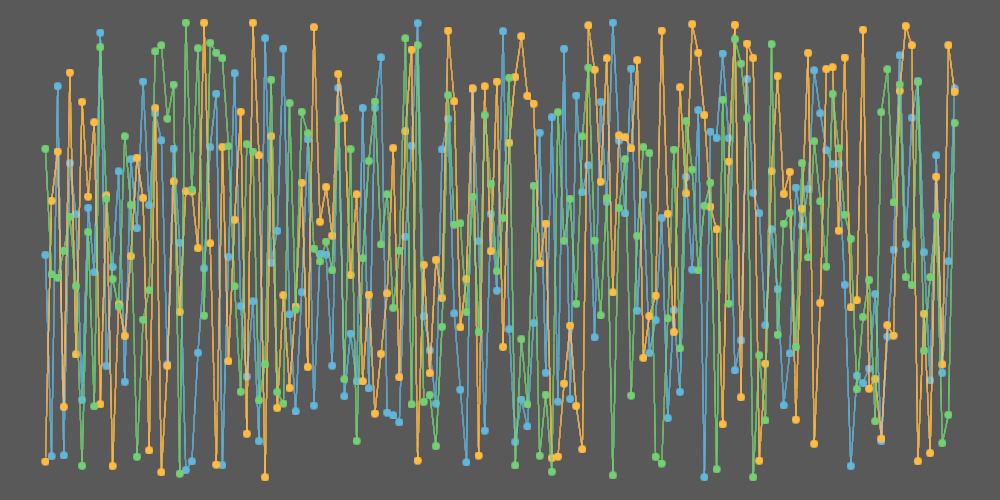

In [6]:

rng = np.random.default_rng(1)
t = np.linspace(0, 1, 150).astype(np.float32)

data_mixed = {
    "small":  (t, (rng.uniform(0, 1, 150)).astype(np.float32)),
    "medium": (t, (rng.uniform(0, 100, 150)).astype(np.float32)),
    "large":  (t, (rng.uniform(0, 10_000, 150)).astype(np.float32)),
}

print("independent_y=False (raw values)")
img = jv.timeline(data_mixed, independent_y=False, width=1000, height=500)
display(Image.fromarray(img, mode='RGBA'))

print("independent_y=True (each series normalised 0→1)")
img = jv.timeline(data_mixed, independent_y=True, width=1000, height=500)
display(Image.fromarray(img, mode='RGBA'))

## 4 — Python datetime objects

timeline: 1 series, 5,806 instances, 1100×500, render 5.2ms


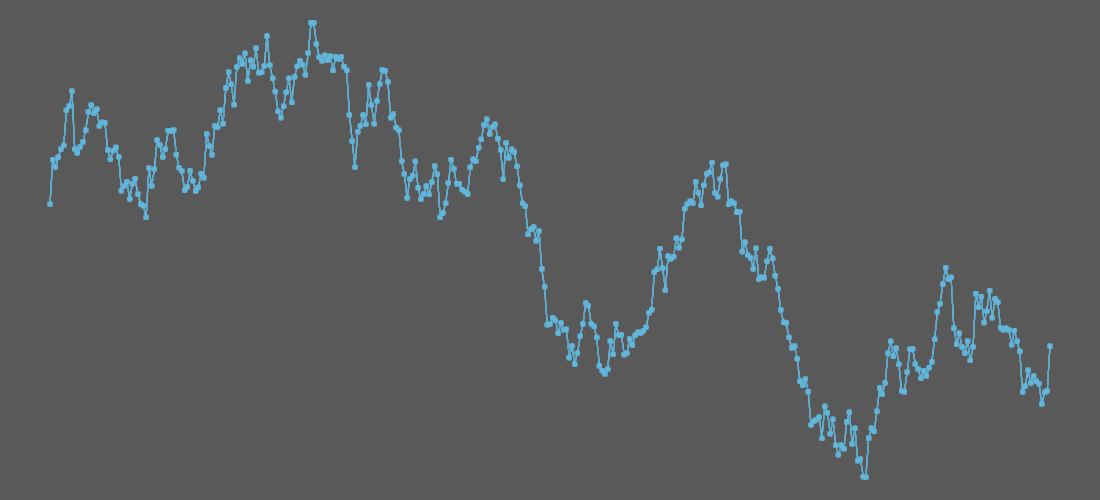

In [4]:
from datetime import datetime, timedelta

rng = np.random.default_rng(3)
start = datetime(2023, 1, 1)
dates = [start + timedelta(days=i) for i in range(365)]
# Cumulative sum → random-walk stock price
returns = rng.normal(0, 1, 365)
price   = 100 + np.cumsum(returns).astype(np.float32)

img = jv.timeline(dates, price, node_size=3.0, edge_size=1.0, edge_opacity=0.8,
                  width=1100, height=500)
display(Image.fromarray(img, mode='RGBA'))

## 5 — From a pandas DataFrame

timeline: 3 series, 36,868 instances, 1100×600, render 11.6ms


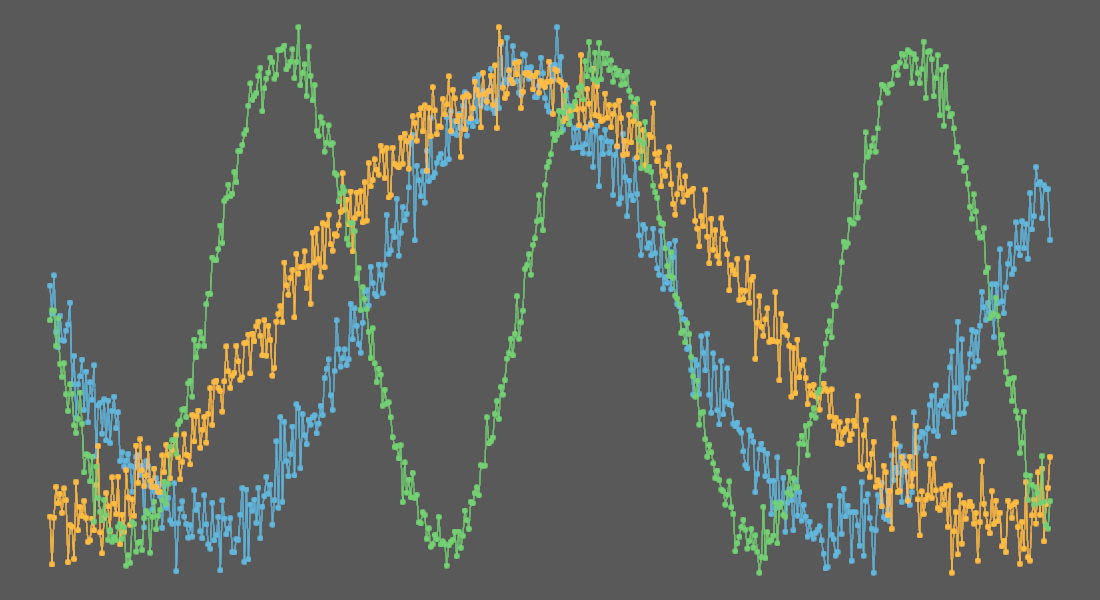

In [7]:
rng = np.random.default_rng(9)
n = 500
t_num = np.linspace(0, 20, n).astype(np.float32)

df = pd.DataFrame({
    "time":    t_num,
    "temp":    (20 + 5 * np.sin(t_num / 2) + rng.normal(0, 0.5, n)).astype(np.float32),
    "humidity":(60 + 10 * np.cos(t_num / 3) + rng.normal(0, 1, n)).astype(np.float32),
    "pressure":(1013 + 5 * np.sin(t_num)    + rng.normal(0, 0.3, n)).astype(np.float32),
})

img = jv.timeline(df, x_col="time", y_cols=["temp", "humidity", "pressure"],
                  independent_y=True,
                  node_size=3.0, edge_size=1.0, edge_opacity=0.65,
                  width=1100, height=600)
display(Image.fromarray(img, mode='RGBA'))

## 6 — numpy `datetime64`

timeline: 1 series, 1,318 instances, 1000×500, render 2.9ms


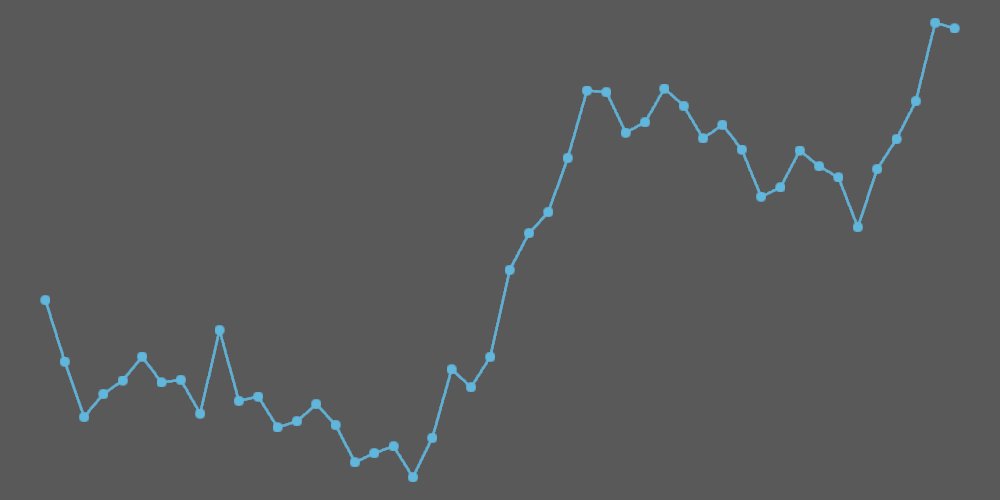

In [8]:
rng = np.random.default_rng(11)
dates64 = np.arange('2020-01', '2024-01', dtype='datetime64[M]')
values  = np.cumsum(rng.normal(0, 2, len(dates64))).astype(np.float32)

img = jv.timeline(dates64, values, node_size=5.0, edge_size=1.5, edge_opacity=0.8,
                  width=1000, height=500)
display(Image.fromarray(img, mode='RGBA'))